# Einführung in Scikit-Learn

Scikit-Learn ist die wichtigste Machine-Learning-Bibliothek für Python.  
In diesem Notebook lernst du die Grundprinzipien kennen, die in **allen** späteren Themen verwendet werden.

## Inhaltsverzeichnis
1. Was ist Scikit-Learn?
2. Die drei Arten von Machine Learning
3. Klassifikation vs. Regression — wann nehme ich was?
4. Wie Scikit-Learn Daten erwartet
5. Die Scikit-Learn API (fit, predict, score)
6. Komplettes Beispiel: Handschriften erkennen
7. Modell speichern und laden


## 1. Was ist Scikit-Learn?

Scikit-Learn (kurz: **sklearn**) ist eine Open-Source-Bibliothek für Machine Learning in Python.  
Sie baut auf NumPy, SciPy und matplotlib auf.

**Warum sklearn?**
- Einheitliche API für alle Algorithmen (du lernst es einmal, verwendest es überall)
- Sehr gut dokumentiert
- Enthält Datensätze zum Üben
- Enthält Werkzeuge für Preprocessing, Evaluation und Hyperparameter-Tuning

**Analogie:** Sklearn ist wie ein Werkzeugkasten — alle Werkzeuge (Algorithmen) funktionieren nach demselben Prinzip: einspannen (fit), benutzen (predict), prüfen (score).


In [1]:
import sklearn
print(f"Scikit-Learn Version: {sklearn.__version__}")

Scikit-Learn Version: 1.6.1


## 2. Die drei Arten von Machine Learning

| Typ | Was passiert | Beispiele |
|-----|-------------|----------|
| **Überwachtes Lernen** (Supervised) | Algorithmus lernt aus **beschrifteten** Daten | Spam-Filter, Hauspreisvorhersage |
| **Unüberwachtes Lernen** (Unsupervised) | Algorithmus findet Muster in **unbeschrifteten** Daten | Kundensegmentierung, Anomalieerkennung |
| **Bestärkendes Lernen** (Reinforcement) | Algorithmus lernt durch Belohnung/Bestrafung | Schach-KI, Robotersteuerung |

In diesem Kurs konzentrieren wir uns hauptsächlich auf **überwachtes Lernen**.


## 3. Klassifikation vs. Regression

**Klassifikation** = Antwort ist eine **Kategorie** (diskret)
- Ist diese E-Mail Spam? → Ja / Nein
- Welche Tierart ist das? → Hund / Katze / Vogel
- Hat der Patient Diabetes? → Ja / Nein

**Regression** = Antwort ist eine **Zahl** (kontinuierlich)
- Was ist der Hauspreis? → 350.000 €
- Wie viel Energie wird verbraucht? → 45,3 kWh
- Welche Note bekomme ich? → 8,4 von 10

> **Faustregel:** Kann man die Antwort auf einer Zahlengeraden platzieren? → Regression. Sortiert sie in Gruppen? → Klassifikation.


## 4. Wie Scikit-Learn Daten erwartet

Sklearn erwartet Daten in einem bestimmten Format:

- **X** (Features/Merkmale): 2D-Array, Form `[n_samples, n_features]`
  - Jede **Zeile** = ein Datenpunkt (z.B. ein Haus)
  - Jede **Spalte** = ein Merkmal (z.B. Zimmeranzahl, Fläche)
- **y** (Zielvariable/Label): 1D-Array, Länge `n_samples`
  - Jedes Element = die "richtige Antwort" für den entsprechenden Datenpunkt

**Begriffe die du kennen solltest:**
- Features = Merkmale = Attribute = Prädiktoren (alle bedeuten dasselbe!)
- Label = Zielvariable = Target = abhängige Variable (alle bedeuten dasselbe!)


In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

# Iris-Datensatz laden (3 Arten von Schwertlilien, 150 Blumen)
iris = load_iris()

X = iris.data   # Features: 4 Merkmale (Blütenblatt-Länge/-Breite etc.)
y = iris.target # Labels: 0=Setosa, 1=Versicolor, 2=Virginica

print(f"Form von X: {X.shape} → {X.shape[0]} Datenpunkte, {X.shape[1]} Merkmale")
print(f"Form von y: {y.shape}")
print(f"Merkmalsnamen: {iris.feature_names}")
print(f"Klassen: {iris.target_names}")

Form von X: (150, 4) → 150 Datenpunkte, 4 Merkmale
Form von y: (150,)
Merkmalsnamen: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Klassen: ['setosa' 'versicolor' 'virginica']


## 5. Die Scikit-Learn API

Das Schöne an sklearn: **alle Algorithmen funktionieren gleich!**

```
1. Modell instanziieren:    modell = AlgorithmusName(hyperparameter=wert)
2. Modell trainieren:       modell.fit(X_train, y_train)
3. Vorhersagen machen:      vorhersagen = modell.predict(X_test)
4. Modell bewerten:         genauigkeit = modell.score(X_test, y_test)
```

**Wichtig: Train/Test-Split**  
Bevor wir trainieren, teilen wir die Daten:
- **Trainingsdaten** (~80%): Davon lernt das Modell
- **Testdaten** (~20%): Damit testen wir, ob das Modell auch auf **neuen** Daten funktioniert

Warum? Stell dir vor, du lernst für eine Prüfung mit denselben Fragen — das sagt dir nichts darüber, ob du wirklich verstanden hast!


In [3]:
from sklearn.model_selection import train_test_split

# Daten aufteilen: 80% Training, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,    # 20% für Test
    random_state=42   # Reproduzierbarkeit
)

print(f"Trainingsdaten: {X_train.shape[0]} Datenpunkte")
print(f"Testdaten:      {X_test.shape[0]} Datenpunkte")

Trainingsdaten: 120 Datenpunkte
Testdaten:      30 Datenpunkte


## 6. Komplettes Beispiel: Handschriften erkennen

Wir verwenden den **Digits-Datensatz**: 1797 Bilder von handgeschriebenen Ziffern (0-9), jedes Bild ist 8x8 Pixel.

**Aufgabe:** Welche Ziffer zeigt das Bild?  
**Typ:** Klassifikation (10 Klassen: 0, 1, 2, ..., 9)


Datensatzgröße: (1797, 64)


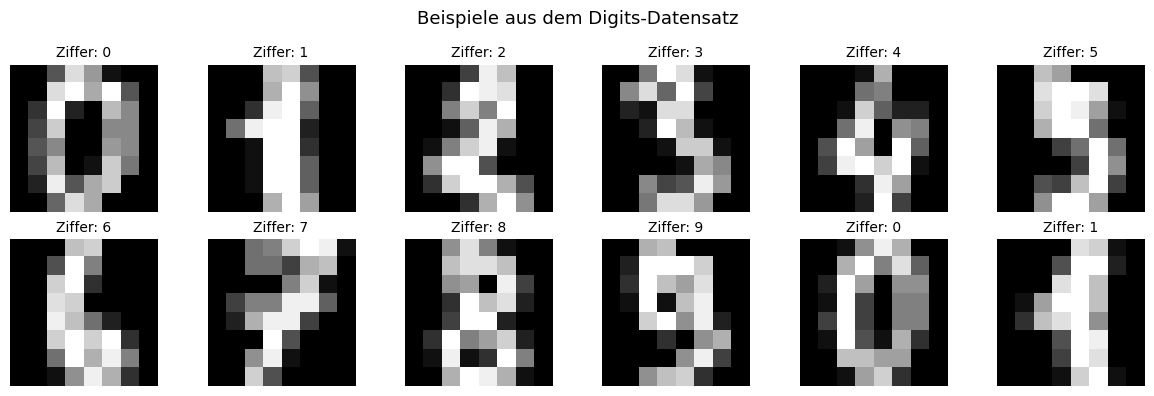

In [4]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

# Datensatz laden
digits = load_digits()
X = digits.data   # 1797 Bilder, jeweils 64 Pixel (8x8 → flachgedrückt)
y = digits.target

print(f"Datensatzgröße: {X.shape}")

# Erste 12 Ziffern anzeigen
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(8, 8), cmap='gray')
    ax.set_title(f"Ziffer: {y[i]}", fontsize=10)
    ax.axis('off')
plt.suptitle("Beispiele aus dem Digits-Datensatz", fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Schritt 1: Daten aufteilen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Schritt 2: Modell erstellen (KNN mit 5 Nachbarn)
modell = KNeighborsClassifier(n_neighbors=5)

# Schritt 3: Modell trainieren
modell.fit(X_train, y_train)

# Schritt 4: Vorhersagen machen
y_pred = modell.predict(X_test)

# Schritt 5: Modell bewerten
genauigkeit = accuracy_score(y_test, y_pred)
print(f"Genauigkeit (Accuracy): {genauigkeit:.2%}")
print()
print("Detaillierter Bericht:")
print(classification_report(y_test, y_pred))

Genauigkeit (Accuracy): 98.61%

Detaillierter Bericht:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       0.98      1.00      0.99        46
           5       0.98      0.96      0.97        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      1.00      1.00        30
           9       0.95      0.95      0.95        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



### Was bedeutet der Classification Report?

| Metrik | Bedeutung | Einfache Erklärung |
|--------|-----------|-------------------|
| **Precision** | Wie oft ist eine positive Vorhersage richtig? | Von allen als "3" vorhergesagten: wie viele waren wirklich "3"? |
| **Recall** | Wie viele positive Fälle wurden erkannt? | Von allen echten "3": wie viele hat das Modell gefunden? |
| **F1-Score** | Mittelwert aus Precision & Recall | Gut wenn beides wichtig ist |
| **Support** | Wie viele Beispiele dieser Klasse im Test? | - |


## 7. Modell speichern und laden

Nach dem Training kann man ein Modell für später speichern — damit muss man nicht jedes Mal neu trainieren.


In [6]:
import pickle

# Modell speichern
with open('mein_modell.pkl', 'wb') as datei:
    pickle.dump(modell, datei)

print("Modell gespeichert!")

# Modell später laden
with open('mein_modell.pkl', 'rb') as datei:
    geladenes_modell = pickle.load(datei)

# Funktioniert genau wie das Original:
probe_prediction = geladenes_modell.predict(X_test[:3])
print(f"Vorhersage für die ersten 3 Testbilder: {probe_prediction}")
print(f"Echte Werte:                             {y_test[:3]}")

Modell gespeichert!
Vorhersage für die ersten 3 Testbilder: [6 9 3]
Echte Werte:                             [6 9 3]


## Zusammenfassung

Was du in diesem Notebook gelernt hast:

1. **Sklearn** = einheitliche API für alle ML-Algorithmen in Python
2. **Supervised Learning** = Lernen aus beschrifteten Daten
3. **Klassifikation** = Vorhersage einer Kategorie; **Regression** = Vorhersage einer Zahl
4. **X** = Features (2D), **y** = Labels (1D)
5. **Train/Test-Split** = immer machen, damit wir wissen ob das Modell wirklich generalisiert
6. **Die 5 Schritte:** instanziieren → fit → predict → score → speichern

Im nächsten Notebook gehen wir tiefer in die **Klassifikationsalgorithmen** ein!
